# Резервная система предсказания типов устройств по имени узла и определения необходимости создания инцидента о событии по ключевым признакам

Этот ноутбук последовательно:
1. Загружает тренировочные данные.
2. Обучает модели для предсказания типов устройств и создания инцидентов.
3. Обрабатывает файлы со списком аварийных сообщений, которые требуется распределить по ролям и завести инциденты где это требуется.


In [1]:
debug = 1

In [2]:
# Общие полезные функции

def log(message):
    if debug == 1:
        print(f"[DEBUG] {message}")

log("Функция log готова. Использование: log(message), будет отображено при включенной отладке.")


#  функция сокрытия конфиденциальных данных для вывода
def show(df):
    df_show = df[0:5].copy()
    df_show['name'] = "Данные скрыты"
    display(df_show.head())

log("Функция show готова. Использование: show(df), значения в столбце name будут скрыты, отображена таблица с примером наполнения.")

# Функция для загрузки данных из Excel-файлов в нормализованном виде

def load_excel_file(file_path):
    try:
        df = pd.read_excel(file_path)
        
        # Приводим колонки к нижнему регистру
        df.columns = [col.lower().strip() for col in df.columns]
        
        # Обрабатываем строковые значения
        for col in df.columns:
            if df[col].dtype == 'object':
                df[col] = df[col].astype(str).str.strip()
                df[col] = df[col].replace('nan', None)
                df[col] = df[col].replace('null', None)
                df[col] = df[col].replace('None', None)
        
        log(f"Загружено {len(df)} строк из файла: {file_path}")
        log(f" Колонки: {list(df.columns)}\n Информация о получившемся датафрейме:")
        # df.info()
        return df
        
    except Exception as e:
        log(f"Ошибка при загрузке файла {file_path}: {e}")
        return None

log("Функция load_excel_file готова. Ипользование: load_excel_file(путь к файлу). Возвращает df.")


[DEBUG] Функция log готова. Использование: log(message), будет отображено при включенной отладке.
[DEBUG] Функция show готова. Использование: show(df), значения в столбце name будут скрыты, отображена таблица с примером наполнения.
[DEBUG] Функция load_excel_file готова. Ипользование: load_excel_file(путь к файлу). Возвращает df.


In [3]:
# Функци для обучения и предсказания роботами

def extract_features_from_name(name):
    """Извлечение признаков из названия устройства"""
    name = str(name)
    features = {}
    
    # 1. Базовые характеристики
    features['length'] = len(name)
    features['num_uppercase'] = sum(1 for c in name if c.isupper())
    features['num_lowercase'] = sum(1 for c in name if c.islower())
    features['num_digits'] = sum(1 for c in name if c.isdigit())
    features['num_special'] = sum(1 for c in name if not c.isalnum() and not c.isspace())
    
    # 2. Наличие определенных префиксов
    common_prefixes = ['X', 'C', 'SX', 'LX', 'BTS', 'UPS', 'MW', 'RRU', 'BBU', 'RRL', 'eCell']
    for prefix in common_prefixes:
        features[f'starts_with_{prefix}'] = int(str(name).startswith(prefix))
    
    # 3. Наличие определенных суффиксов
    common_suffixes = ['atn', 'agg', 'acc', 'D', 'G', 'L', 'GL', 'GUL', 'GLT', 'GULT', 'VCMTS', 'MTSVC', 'BTS', 'Cell', 'eCell', 'UPS', 'Switch']
    for suffix in common_suffixes:
        features[f'ends_with_{suffix}'] = int(str(name).endswith(suffix))
    
    # 4. Структурные элементы
    features['num_underscores'] = name.count('_')
    features['num_hyphens'] = name.count('-')
    features['num_commas'] = name.count(',')
    features['num_spaces'] = name.count(' ')
    features['num_slashes'] = name.count('/')
    features['num_colons'] = name.count(':')
    
    # 5. Паттерны в названии
    features['has_number_sequence'] = int(bool(re.search(r'\d{3,}', name)))
    features['has_letter_number_pattern'] = int(bool(re.search(r'[A-Za-z]_\d+', name)))
    features['has_ip_like'] = int(bool(re.search(r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', name)))
    
    # 6. Соотношения
    if features['length'] > 0:
        features['digit_ratio'] = features['num_digits'] / features['length']
        features['letter_ratio'] = (features['num_uppercase'] + features['num_lowercase']) / features['length']
        features['special_ratio'] = features['num_special'] / features['length']
        features['upper_ratio'] = features['num_uppercase'] / features['length'] if features['num_uppercase'] > 0 else 0
    else:
        features['digit_ratio'] = 0
        features['letter_ratio'] = 0
        features['special_ratio'] = 0
        features['upper_ratio'] = 0
    
    return features
log("Функция extract_features_from_name готова к использованию.")

# функции предсказания типа устройства и ролей
def predict_device_type(names):
    """Предсказание типов для списка названий"""
    if isinstance(names, str):
        names = [names]
    
    # Извлекаем признаки
    features_list = []
    for name in names:
        features_list.append(extract_features_from_name(name))
    
    X = pd.DataFrame(features_list)
    
    # Предсказываем
    predictions = device_classifier.predict(X)
    probabilities = device_classifier.predict_proba(X)
    
    # Декодируем
    predicted_types = device_label_encoder.inverse_transform(predictions)
    
    # Добавляем уверенность
    results = []
    for i, (pred_type, probs) in enumerate(zip(predicted_types, probabilities)):
        confidence = max(probs)
        
        # Топ-3 предсказания
        top_indices = np.argsort(probs)[-3:][::-1]
        top_predictions = []
        for idx in top_indices:
            if probs[idx] > 0.05:
                top_predictions.append({
                    'type': device_label_encoder.inverse_transform([idx])[0],
                    'probability': probs[idx]
                })
        
        results.append({
            'name': names[i],
            'predicted_type': pred_type,
            'confidence': confidence,
            'top_3': top_predictions
        })
    
    return results
log("Функция predict_device_type готова к использованию")
    

def predict_role(device_types):
    """Предсказание role по типу устройства"""
    if isinstance(device_types, str):
        device_types = [device_types]
    
    results = []
    for dt in device_types:
        if dt in role_mapping:
            role = role_mapping[dt]
            confidence = role_probabilities[dt].get(role, 1.0)
            results.append({
                'role': role,
                'confidence': confidence,
                'method': 'mapping',
                'name': dt
            })
        else:
            results.append({
                'role': 'Unknown',
                'confidence': 0,
                'method': 'unknown',
                'name': dt
            })
    
    return results

log("Функция predict_role готова к использованию")

# ФУНКЦИЯ ПРЕДСКАЗАНИЯ ЗАВЕДЕНИЯ ТТ!
def predict_create(device_types, severities, roles, events):
    """Предсказание create (0/1) с использованием расширенного набора признаков"""
    
    # ПРЕОБРАЗОВАНИЕ ВХОДНЫХ ДАННЫХ В СТРОКИ
    device_types = [str(x) if x is not None else 'Unknown' for x in device_types]
    roles = [str(x) if x is not None else 'Unknown' for x in roles]
    events = [str(x) if x is not None else 'Unknown' for x in events]
    
    # Создаем DataFrame для одной записи
    pred_df = pd.DataFrame({
        'devicetype': device_types,
        'severity': severities,
        'role': roles,
        'event': events
    })

    # 1. Комбинированные признаки (конкатенация строк)
    pred_df['devicetype_role'] = pred_df['devicetype'] + '_' + pred_df['role']
    pred_df['devicetype_event'] = pred_df['devicetype'] + '_' + pred_df['event']
    pred_df['devicetype_event_role'] = pred_df['devicetype'] + '_' + pred_df['event'] + '_' + pred_df['role']

    # 2. Частотные признаки (используем частоты из обучающей выборки df_features)
    for col in ['devicetype', 'severity', 'role', 'devicetype_severity', 'devicetype_role', 
                'devicetype_event', 'devicetype_event_role', 'devicetype_severity_role']:
        if col in df_features.columns:
            # Используем частоты из обучающей выборки, а не из тестовой
            freq_map = df_features[col].value_counts(normalize=True).to_dict()
            pred_df[f'{col}_frequency'] = pred_df[col].map(freq_map).fillna(0)

    # 3. Целевой энкодинг (среднее значение create для каждой категории)
    print(" Создание target mean признаков...")
    
    # Используем глобальное среднее из обучающей выборки
    global_mean = df_features['create'].mean() if 'create' in df_features.columns else 0.5
    
    for col in ['devicetype', 'severity', 'role', 'devicetype_severity', 'devicetype_role', 'severity_role']:
        if col in df_features.columns:
            # Среднее по группе из обучающей выборки
            target_mean = df_features.groupby(col)['create'].mean().to_dict()
            
            # Прямой target mean
            pred_df[f'{col}_target_mean'] = pred_df[col].map(target_mean).fillna(global_mean)
            
            # Сглаженный target mean (с регуляризацией)
            group_counts = df_features[col].value_counts().to_dict()
            pred_df[f'{col}_target_mean_smoothed'] = pred_df[col].map(
                lambda x: (target_mean.get(x, global_mean) * group_counts.get(x, 0) + global_mean * 10) / 
                          (group_counts.get(x, 0) + 10)
            ).fillna(global_mean)
    
    # 4. Статистические признаки
    for col in ['devicetype', 'role', 'severity', 'event']:
        if col in df_features.columns:
            create_rate = df_features.groupby(col)['create'].mean().to_dict()
            count_map = df_features[col].value_counts().to_dict()
            
            pred_df[f'{col}_create_rate'] = pred_df[col].map(lambda x: create_rate.get(x, global_mean)).fillna(global_mean)
            pred_df[f'{col}_count'] = pred_df[col].map(lambda x: count_map.get(x, 1)).fillna(1).astype(int)
    
    # 5. Кодируем для мультипликативных признаков
    for col in ['devicetype', 'severity', 'role', 'event']:
        if col in globals().get('temp_encoders', {}):
            # Для неизвестных значений используем 0
            pred_df[f'{col}_num'] = pred_df[col].map(
                lambda x: temp_encoders[col].transform([x])[0] if x in temp_encoders[col].classes_ else 0
            ).fillna(0).astype(int)
    
    # Мультипликативные признаки
    if all(f'{col}_num' in pred_df.columns for col in ['devicetype', 'severity', 'role', 'event']):
        pred_df['devicetype_x_severity'] = pred_df['devicetype_num'] * pred_df['severity_num']
        pred_df['devicetype_x_role'] = pred_df['devicetype_num'] * pred_df['role_num']
        pred_df['severity_x_role'] = pred_df['severity_num'] * pred_df['role_num']
        pred_df['all_interactions'] = pred_df['devicetype_num'] * pred_df['severity_num'] * pred_df['role_num']
    
    # Выбираем только нужные признаки
    available_features = [col for col in globals().get('available_features', []) 
                         if col != 'create']  # исключаем create из признаков

    X_pred = pd.DataFrame()
    for col in available_features:
        if col in pred_df.columns:
            X_pred[col] = pred_df[col]
        else:
            X_pred[col] = 0  # Заполняем пропуски нулями
    
    # Проверяем на наличие пропусков
    X_pred = X_pred.fillna(0)
    
    # Проверяем, что все колонки числовые
    for col in X_pred.columns:
        if not pd.api.types.is_numeric_dtype(X_pred[col]):
            X_pred[col] = pd.to_numeric(X_pred[col], errors='coerce').fillna(0)
    
    # Масштабируем (если используется)
    if 'scaler' in globals():
        X_pred_scaled = scaler.transform(X_pred)
    else:
        X_pred_scaled = X_pred.values
    
    # Предсказываем
    predictions = create_classifier.predict(X_pred_scaled)
    probabilities = create_classifier.predict_proba(X_pred_scaled)
    
    results = []
    for i, (pred, probs) in enumerate(zip(predictions, probabilities)):
        # Убеждаемся, что probs имеет правильную длину
        if len(probs) >= 2:
            prob_class1 = probs[1]
            confidence = probs[1] if pred == 1 else probs[0]
        else:
            prob_class1 = 0.5
            confidence = 0.5
            
        results.append({
            'create': int(pred),
            'probability_class1': prob_class1,
            'confidence': confidence
        })
    
    log(f"Создано {len(results)} предсказаний")

    # Дебаг потом
    #predictions = create_classifier.predict(X_pred_scaled)
    #probabilities = create_classifier.predict_proba(X_pred_scaled)
    
    #log(f"predictions[:5]: {predictions[:5]}")
    #log(f"probabilities[:5]: {probabilities[:5]}")
    #log(f"Форма probabilities shape: {probabilities.shape}")
    return results
    
log("Функция predict_create_enhanced готова")

[DEBUG] Функция extract_features_from_name готова к использованию.
[DEBUG] Функция predict_device_type готова к использованию
[DEBUG] Функция predict_role готова к использованию
[DEBUG] Функция predict_create_enhanced готова


In [4]:
# загрузка библиотек
import re
import os
import pandas as pd
import numpy as np
from collections import Counter
from difflib import SequenceMatcher
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
# from IPython.display import display, HTML
import matplotlib.pyplot as plt
import seaborn as sns
log("Требуемые библиотеки загружены.")

[DEBUG] Требуемые библиотеки загружены.


In [5]:
# Загрузка данных для тренировки моделей

# Файл с name и devicetype
TRAIN_DEVICE_FILE = "training_devicetype.xlsx"
df_device_train = load_excel_file(TRAIN_DEVICE_FILE)
if df_device_train is None:
    raise ValueError("Не удалось загрузить файл с типами устройств")
else:
    # Создаем копию для отображения результата
    show(df_device_train)

[DEBUG] Загружено 100000 строк из файла: training_devicetype.xlsx
[DEBUG]  Колонки: ['name', 'devicetype']
 Информация о получившемся датафрейме:


,name,devicetype
0,Данные скрыты,MEN
1,Данные скрыты,DWDM
2,Данные скрыты,eNodeB
3,Данные скрыты,Cell
4,Данные скрыты,BSC


In [6]:
# Файл со списком правильно обработанных ранее аварий со всеми заполненными полями
TRAIN_FULL_FILE = "training_full.xlsx"
df_full_train = load_excel_file(TRAIN_FULL_FILE)
if df_full_train is None:
    raise ValueError("Не удалось загрузить полный файл")
else:
    # Создаем копию для отображения результата
    show(df_full_train)

[DEBUG] Загружено 96546 строк из файла: training_full.xlsx
[DEBUG]  Колонки: ['name', 'devicetype', 'severity', 'event', 'role', 'lifetime_more_5min', 'create']
 Информация о получившемся датафрейме:


,name,devicetype,severity,event,role,lifetime_more_5min,create
0,Данные скрыты,Router,0,unreachable,Эксплуатация транспорта,1,0
1,Данные скрыты,UPS,0,rectifier-Fail (4),Эксплуатация транспорта,1,1
2,Данные скрыты,MW Station,0,Routing Table Hardware resources operation fail,Эксплуатация транспорта,1,0
3,Данные скрыты,MEN,4,Tunnel Transmitting Services Is Unreachable,Эксплуатация транспорта,1,0
4,Данные скрыты,eNodeB,0,External alarm type 1. AC fault.,Региональный мониторинг,1,1


In [7]:
# Обучение модели для предсказания типа устройства по названию

train_device_df = df_device_train[df_device_train['devicetype'].notna()].copy()

log("Всего примеров для обучения:" + str({len(train_device_df)}))
log("Уникальных типов устройств:" + str({train_device_df['devicetype'].nunique()}))

type_counts = train_device_df['devicetype'].value_counts()
unique_types = type_counts.index.tolist()


[DEBUG] Всего примеров для обучения:{100000}
[DEBUG] Уникальных типов устройств:{9}


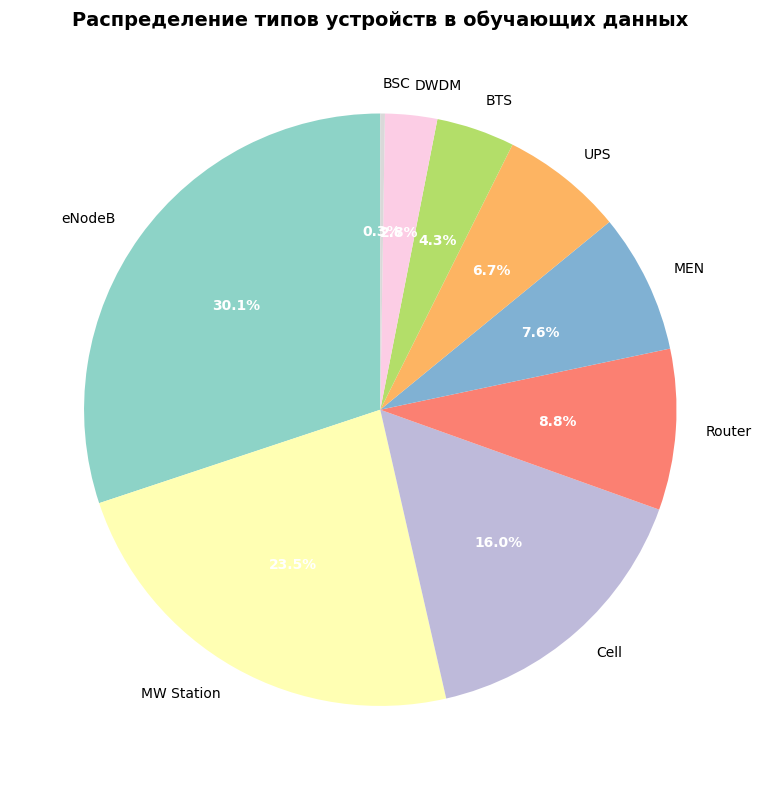

In [8]:
# Круговая диаграмма для топ-10 типов
fig, ax = plt.subplots(figsize=(10, 8))

# Создаем круговую диаграмму
colors = plt.cm.Set3(range(len(type_counts.values)))
wedges, texts, autotexts = ax.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
                                   colors=colors, startangle=90,
                                   textprops={'fontsize': 10})

# Настраиваем внешний вид
for text in texts:
    text.set_fontsize(10)
    
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title('Распределение типов устройств в обучающих данных', fontsize=14, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

In [9]:
# Извлекаем признаки из наименований
device_features_list = []
for name in train_device_df['name']:
    device_features_list.append(extract_features_from_name(name))

# Создаем DataFrame с признаками
X_device = pd.DataFrame(device_features_list)
device_feature_names = X_device.columns.tolist()

# Кодируем целевую переменную
device_label_encoder = LabelEncoder()
y_device = device_label_encoder.fit_transform(train_device_df['devicetype'])

# Обучаем классификатор
device_classifier = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

device_classifier.fit(X_device, y_device)

# Сохраняем статистику
device_type_statistics = train_device_df['devicetype'].value_counts().to_dict()

log("Модель обучена сопоставлять имена с типом устройств")
log(str(device_type_statistics))

[DEBUG] Модель обучена сопоставлять имена с типом устройств
[DEBUG] {'eNodeB': 30107, 'MW Station': 23466, 'Cell': 15953, 'Router': 8785, 'MEN': 7617, 'UPS': 6708, 'BTS': 4273, 'DWDM': 2839, 'BSC': 252}



  Топ-10 наиболее важных признаков:
    letter_ratio: 0.112
    digit_ratio: 0.093
    num_digits: 0.085
    length: 0.082
    ends_with_UPS: 0.079
    num_underscores: 0.067
    special_ratio: 0.063
    upper_ratio: 0.061
    starts_with_BTS: 0.052
    num_uppercase: 0.047


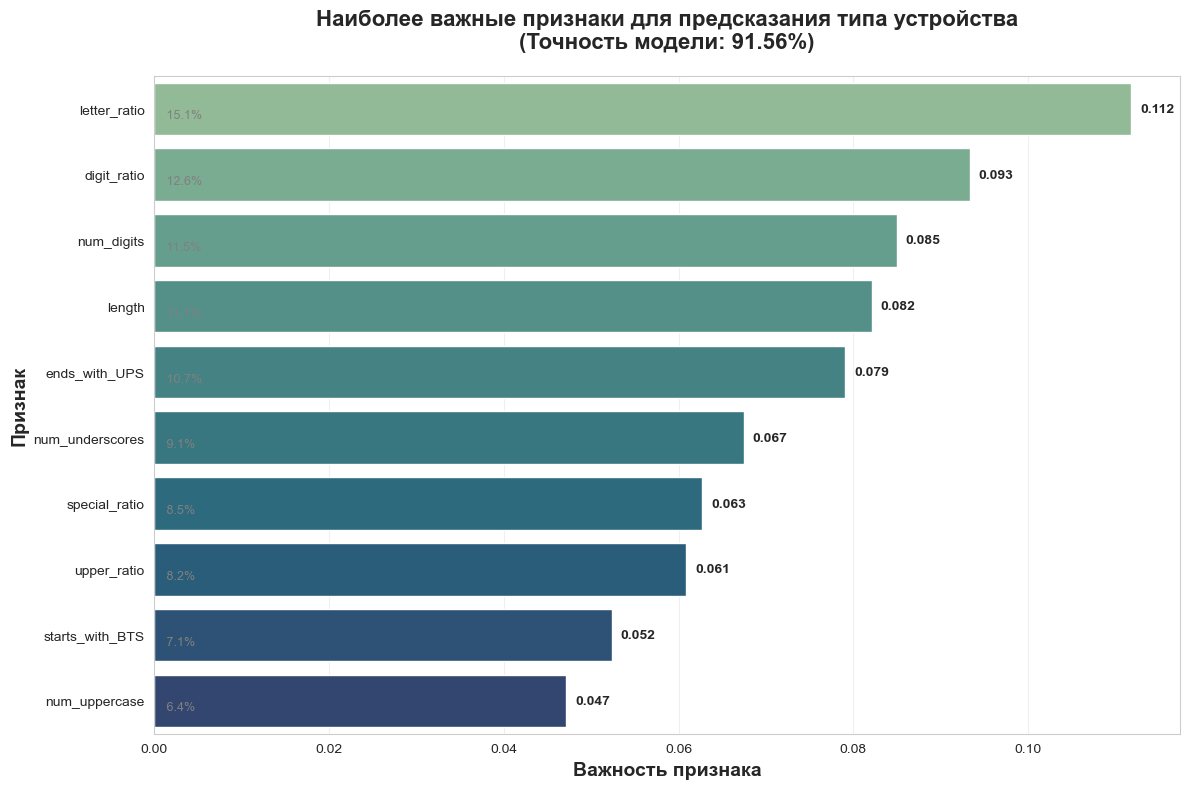

In [10]:
# Оценка важностей признаков:
if len(train_device_df) >= 50:
    X_train, X_test, y_train, y_test = train_test_split(X_device, y_device, test_size=0.2, random_state=42)
    device_classifier.fit(X_train, y_train)
    y_pred = device_classifier.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Показываем топ-10 наиболее важных признаков
    feature_importance = pd.DataFrame({
        'feature': device_feature_names,
        'importance': device_classifier.feature_importances_
    }).sort_values('importance', ascending=False).head(10)
    
    print("\n  Топ-10 наиболее важных признаков:")
    for _, row in feature_importance.head(10).iterrows():
        print(f"    {row['feature']}: {row['importance']:.3f}")
            
    # Настройка стиля
    sns.set_style("whitegrid")
    plt.figure(figsize=(12, 8))
    
    # Создаем цветовую шкалу на основе важности
    colors = sns.color_palette("crest", len(feature_importance))
    
    # Горизонтальный барплот
    ax = sns.barplot(data=feature_importance, y='feature', x='importance', 
                     palette=colors, orient='h')
    
    # Добавляем значения на столбцы
    for i, (_, row) in enumerate(feature_importance.iterrows()):
        ax.text(row['importance'] + 0.001, i, f'{row["importance"]:.3f}', 
                va='center', fontsize=10, fontweight='bold')
    
    # Настройка заголовков
    ax.set_xlabel('Важность признака', fontsize=14, fontweight='bold')
    ax.set_ylabel('Признак', fontsize=14, fontweight='bold')
    ax.set_title(f'Наиболее важные признаки для предсказания типа устройства\n(Точность модели: {accuracy:.2%})', 
                 fontsize=16, fontweight='bold', pad=20)
    
    # Добавляем сетку для лучшей читаемости
    ax.grid(True, axis='x', alpha=0.3)
    
    # Добавляем подписи с процентами
    total_importance = feature_importance['importance'].sum()
    for i, (_, row) in enumerate(feature_importance.iterrows()):
        percentage = (row['importance'] / total_importance) * 100
        ax.text(0.001, i + 0.1, f' {percentage:.1f}%', 
                va='center', fontsize=9, color='gray')
    
    plt.tight_layout()
    plt.show()
    

In [11]:
# Создание справочника ролей по типу устройства

# Фильтруем строки с известными role и devicetype
known_role_df = df_full_train[df_full_train['role'].notna() & df_full_train['devicetype'].notna()].copy()
log("Размер тренировочного набора данных = " + str(len(known_role_df)) + " записей для последующего анализа.")

# Создаем справочник
role_mapping = {}
role_probabilities = {}

for device_type in known_role_df['devicetype'].unique():
    type_roles = known_role_df[known_role_df['devicetype'] == device_type]['role']
    if len(type_roles) > 0:
        # Находим наиболее частый role
        role_counts = type_roles.value_counts()
        most_common_role = role_counts.index[0]
        role_mapping[device_type] = most_common_role
        
        # Сохраняем вероятности
        total = len(type_roles)
        role_probabilities[device_type] = {
            role: count/total for role, count in role_counts.items()
        }

log(f"Создан справочник для {len(role_mapping)} типов устройств")

# Показываем примеры
print("\nПримеры наиболее частовстречаемых соответствий тип - роль:")
for device_type, role in list(role_mapping.items()):
    confidence = role_probabilities[device_type].get(role, 0)
    print(f"  {device_type:20} -- {role} (уверенность: {confidence:.1%})")

[DEBUG] Размер тренировочного набора данных = 96546 записей для последующего анализа.
[DEBUG] Создан справочник для 9 типов устройств

Примеры наиболее частовстречаемых соответствий тип - роль:
  Router               -- Эксплуатация транспорта (уверенность: 100.0%)
  UPS                  -- Поддержка БС (уверенность: 41.5%)
  MW Station           -- Эксплуатация транспорта (уверенность: 100.0%)
  MEN                  -- Эксплуатация транспорта (уверенность: 100.0%)
  eNodeB               -- Поддержка БС (уверенность: 32.8%)
  Cell                 -- Сетевой отдел (уверенность: 54.5%)
  DWDM                 -- Федеральный мониторинг (уверенность: 99.5%)
  BTS                  -- Поддержка БС (уверенность: 58.9%)
  BSC                  -- Отдел роуминга (уверенность: 100.0%)


In [12]:
# Фильтруем строки с полными данными
train_create_df = df_full_train[
    df_full_train['devicetype'].notna() & 
    df_full_train['severity'].notna() & 
    df_full_train['event'].notna() & 
    df_full_train['role'].notna() & 
    df_full_train['create'].notna()
].copy()

log(f"Процент заведения аварии в инцидент (поле create) в тренировочных данных ({len(train_create_df)} строк):")
log(f"  create=1: {(train_create_df['create'] == 1).sum()} ({((train_create_df['create'] == 1).mean()*100):.1f}%)")
log(f"  create=0: {(train_create_df['create'] == 0).sum()} ({((train_create_df['create'] == 0).mean()*100):.1f}%)")


[DEBUG] Процент заведения аварии в инцидент (поле create) в тренировочных данных (96546 строк):
[DEBUG]   create=1: 8979 (9.3%)
[DEBUG]   create=0: 87567 (90.7%)


# ИНЖИНИРИНГ ПРИЗНАКОВ (FEATURE ENGINEERING)

In [13]:
# Копируем данные для создания признаков и нормализуем их (встречаются цифробуквенные или только номерные события)
df_features = train_create_df.copy()

# ПРЕОБРАЗОВАНИЕ ВСЕХ КАТЕГОРИАЛЬНЫХ ПОЛЕЙ В СТРОКИ
for col in ['devicetype', 'event', 'role']:
    df_features[col] = df_features[col].astype(str)

log(" Все категориальные поля преобразованы в строковый тип.")

[DEBUG]  Все категориальные поля преобразованы в строковый тип.


In [14]:
# 1. Комбинированные признаки (конкатенация строк)
df_features['devicetype_role'] = df_features['devicetype'] + '_' + df_features['role']
df_features['devicetype_event'] = df_features['devicetype'] + '_' + df_features['event']
df_features['devicetype_event_role'] = df_features['devicetype'] + '_' + df_features['event'] + '_' + df_features['role']

# 2. Частотные признаки (как часто встречается комбинация)
for col in ['devicetype', 'severity', 'role', 'devicetype_role', 'devicetype_event', 'devicetype_event_role',]:
    freq_map = df_features[col].value_counts().to_dict()
    df_features[f'{col}_frequency'] = df_features[col].map(freq_map).fillna(0).astype(int)

# 3. Целевой энкодинг (среднее значение create для каждой категории)
log(" Создание target mean признаков...")

global_mean = df_features['create'].mean()

for col in ['devicetype', 'severity', 'role', 'devicetype_role']:
    # Среднее по группе
    target_mean = df_features.groupby(col)['create'].mean()
    
    # Прямой target mean
    df_features[f'{col}_target_mean'] = df_features[col].map(target_mean).fillna(global_mean)
    
    # Сглаженный target mean (с регуляризацией)
    group_counts = df_features[col].value_counts()
    df_features[f'{col}_target_mean_smoothed'] = df_features[col].map(
        lambda x: (target_mean.get(x, global_mean) * group_counts.get(x, 0) + global_mean * 10) / 
                  (group_counts.get(x, 0) + 10)
    ).fillna(global_mean)

# 5. Статистические признаки по группам
log(" Создание статистических признаков...")

for group_col in ['devicetype', 'role', 'severity', 'event']:
    # Частота create=1 в группе
    create_rate = df_features.groupby(group_col)['create'].mean()
    df_features[f'{group_col}_create_rate'] = df_features[group_col].map(create_rate).fillna(global_mean)
    
    # Размер группы
    group_size = df_features[group_col].value_counts()
    df_features[f'{group_col}_count'] = df_features[group_col].map(group_size).fillna(1).astype(int)

# 6. Признаки взаимодействия (мультипликативные)
log(" Создание мультипликативных признаков...")

# Кодируем категориальные переменные для мультипликативных признаков
temp_encoders = {}
for col in ['devicetype', 'severity', 'role']:
    temp_encoders[col] = LabelEncoder()
    # Обрабатываем возможные пропуски
    df_features[f'{col}_num'] = temp_encoders[col].fit_transform(df_features[col].fillna('Unknown'))

# Создаем мультипликативные признаки (произведение кодированных значений)
df_features['devicetype_x_severity'] = df_features['devicetype_num'] * df_features['severity_num']
df_features['devicetype_x_role'] = df_features['devicetype_num'] * df_features['role_num']
df_features['severity_x_role'] = df_features['severity_num'] * df_features['role_num']
df_features['all_interactions'] = (df_features['devicetype_num'] * 
                                   df_features['severity_num'] * 
                                   df_features['role_num'])

log(f" Создано признаков: {len(df_features.columns) - len(train_create_df.columns)}")

[DEBUG]  Создание target mean признаков...
[DEBUG]  Создание статистических признаков...
[DEBUG]  Создание мультипликативных признаков...
[DEBUG]  Создано признаков: 32


In [15]:
# Создаем DataFrame из списка колонок
columns_df = pd.DataFrame({
    'Название признака': df_features.columns,
    'Тип данных': df_features.dtypes.values,
    'Уникальных значений': df_features.nunique().values
})

print("Признаки:")
print(columns_df.to_string(index=True))

Признаки:
                       Название признака Тип данных  Уникальных значений
0                                   name     object                14269
1                             devicetype     object                    9
2                               severity      int64                    6
3                                  event     object                  593
4                                   role     object                   10
5                     lifetime_more_5min      int64                    2
6                                 create      int64                    2
7                        devicetype_role     object                   32
8                       devicetype_event     object                  614
9                  devicetype_event_role     object                  744
10                  devicetype_frequency      int64                    9
11                    severity_frequency      int64                    6
12                        role_frequency 

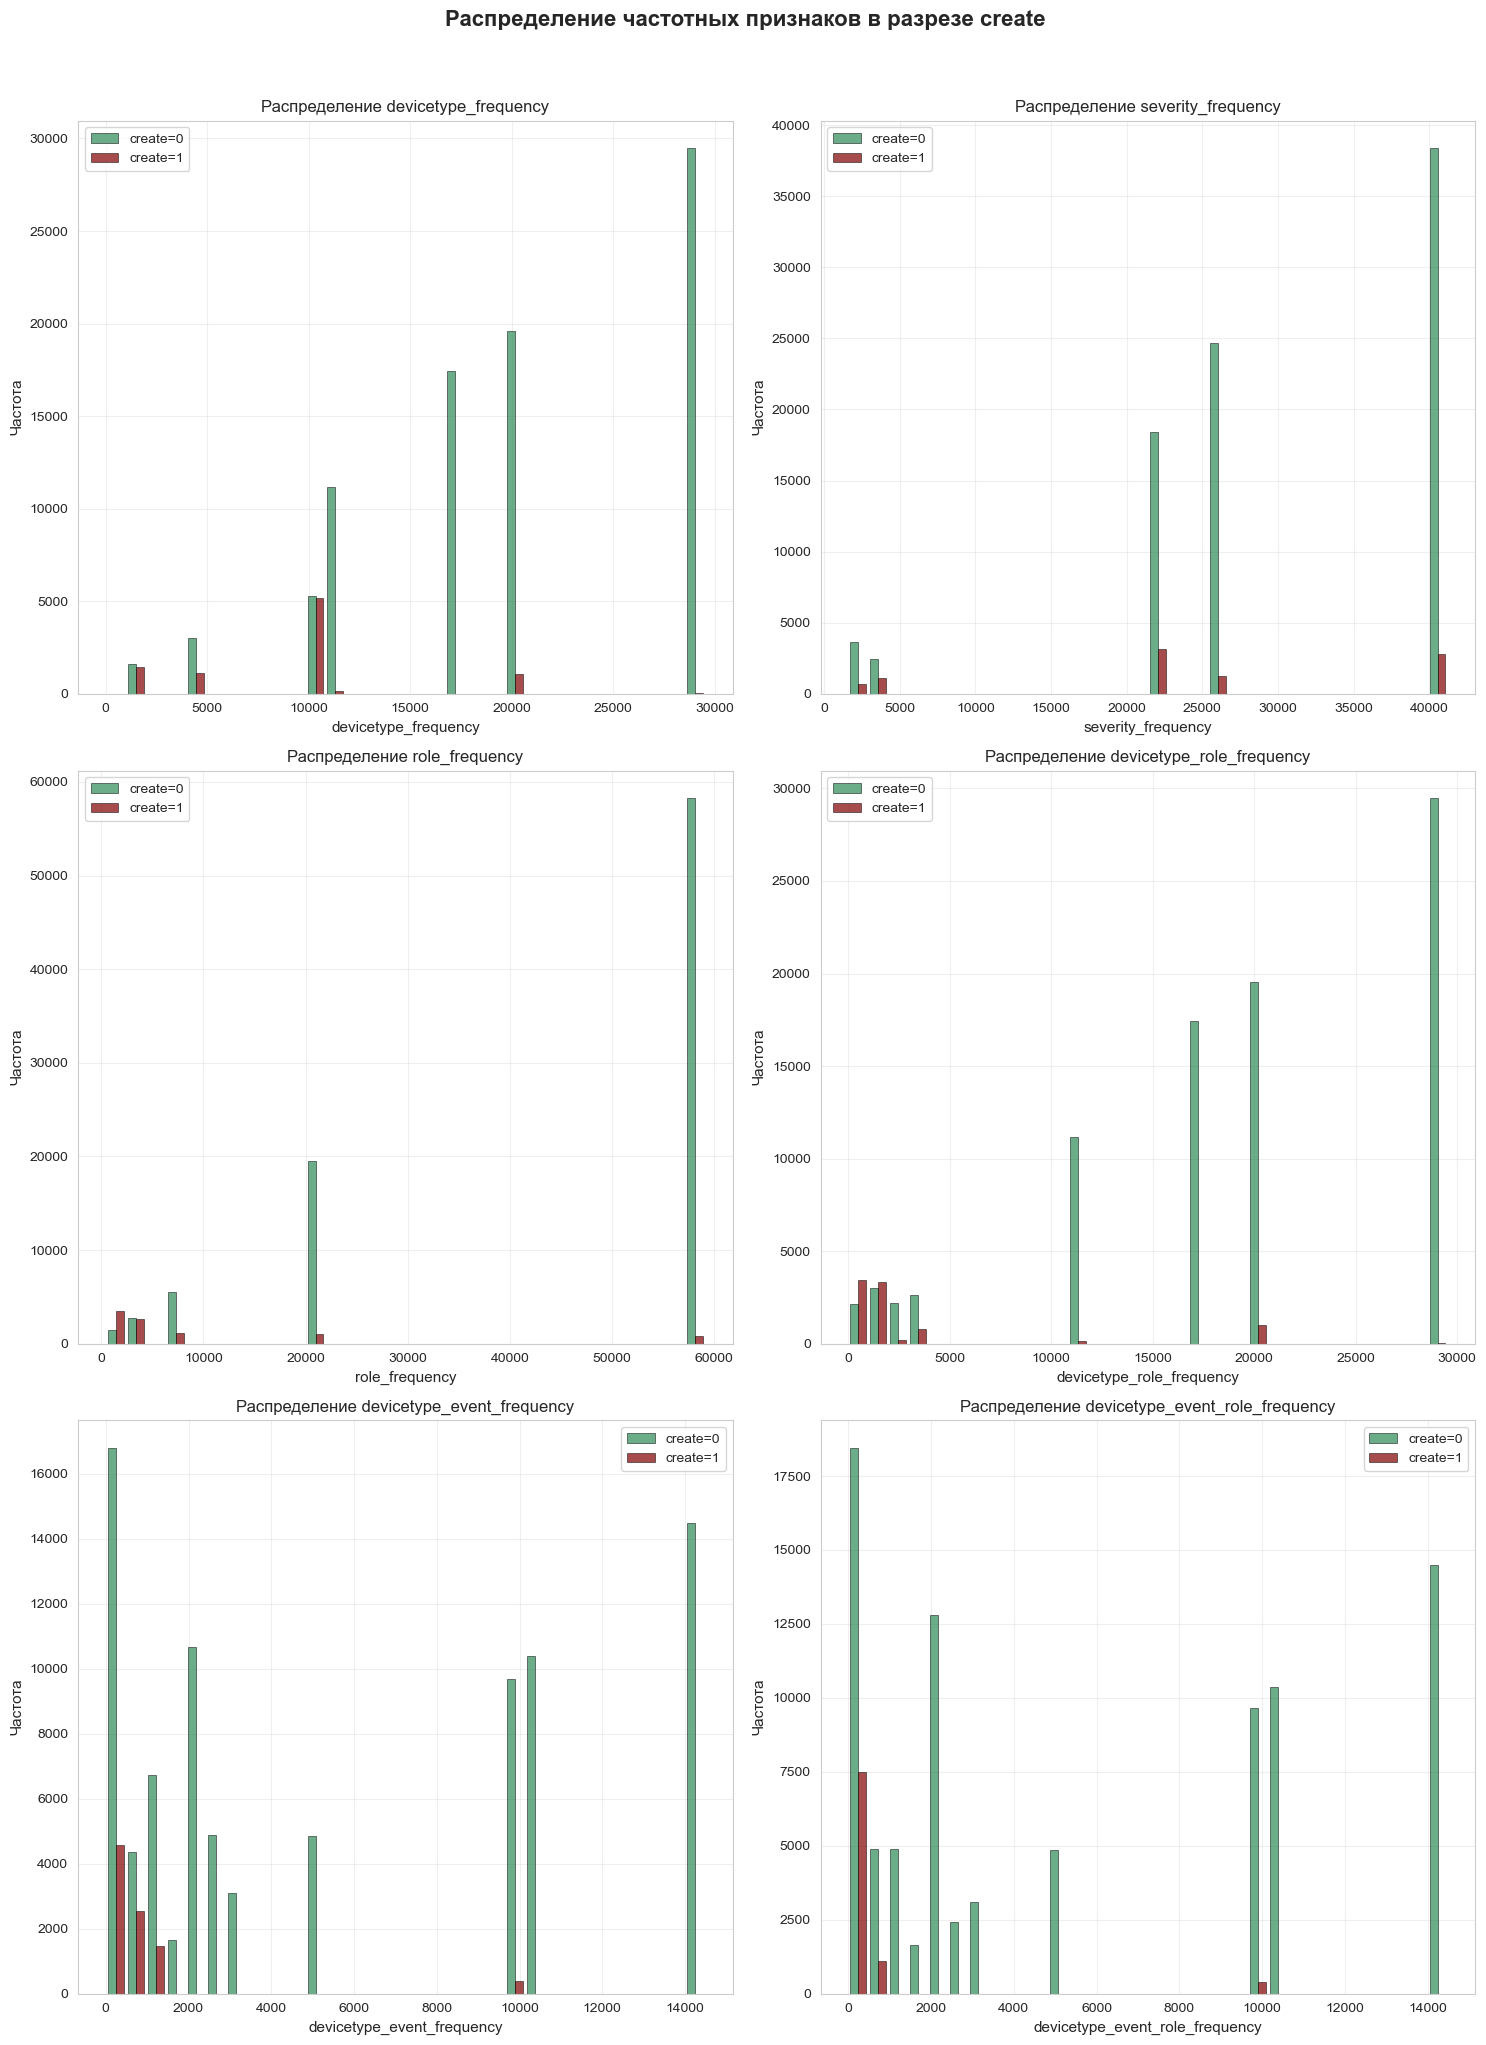

In [16]:
# Распределение частотных признаков в разрезе create

# Настройка стиля
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

fig, axes = plt.subplots(3, 2, figsize=(15, 20))
fig.suptitle('Распределение частотных признаков в разрезе create', fontsize=16, fontweight='bold', y=1.02)

freq_cols = ['devicetype_frequency', 'severity_frequency', 'role_frequency', 
             'devicetype_role_frequency', 'devicetype_event_frequency', 
             'devicetype_event_role_frequency']

for i, col in enumerate(freq_cols):
    if col in df_features.columns:
        ax = axes[i//2, i%2]
        
        # Разделяем по create
        data_0 = df_features[df_features['create'] == 0][col]
        data_1 = df_features[df_features['create'] == 1][col]
        
        # Строим гистограммы
        ax.hist([data_0, data_1], bins=30, alpha=0.7, label=['create=0', 'create=1'], 
                color=['seagreen', 'maroon'], edgecolor='black', linewidth=0.5)
        
        ax.set_xlabel(col, fontsize=11)
        ax.set_ylabel('Частота', fontsize=11)
        ax.set_title(f'Распределение {col}', fontsize=12)
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


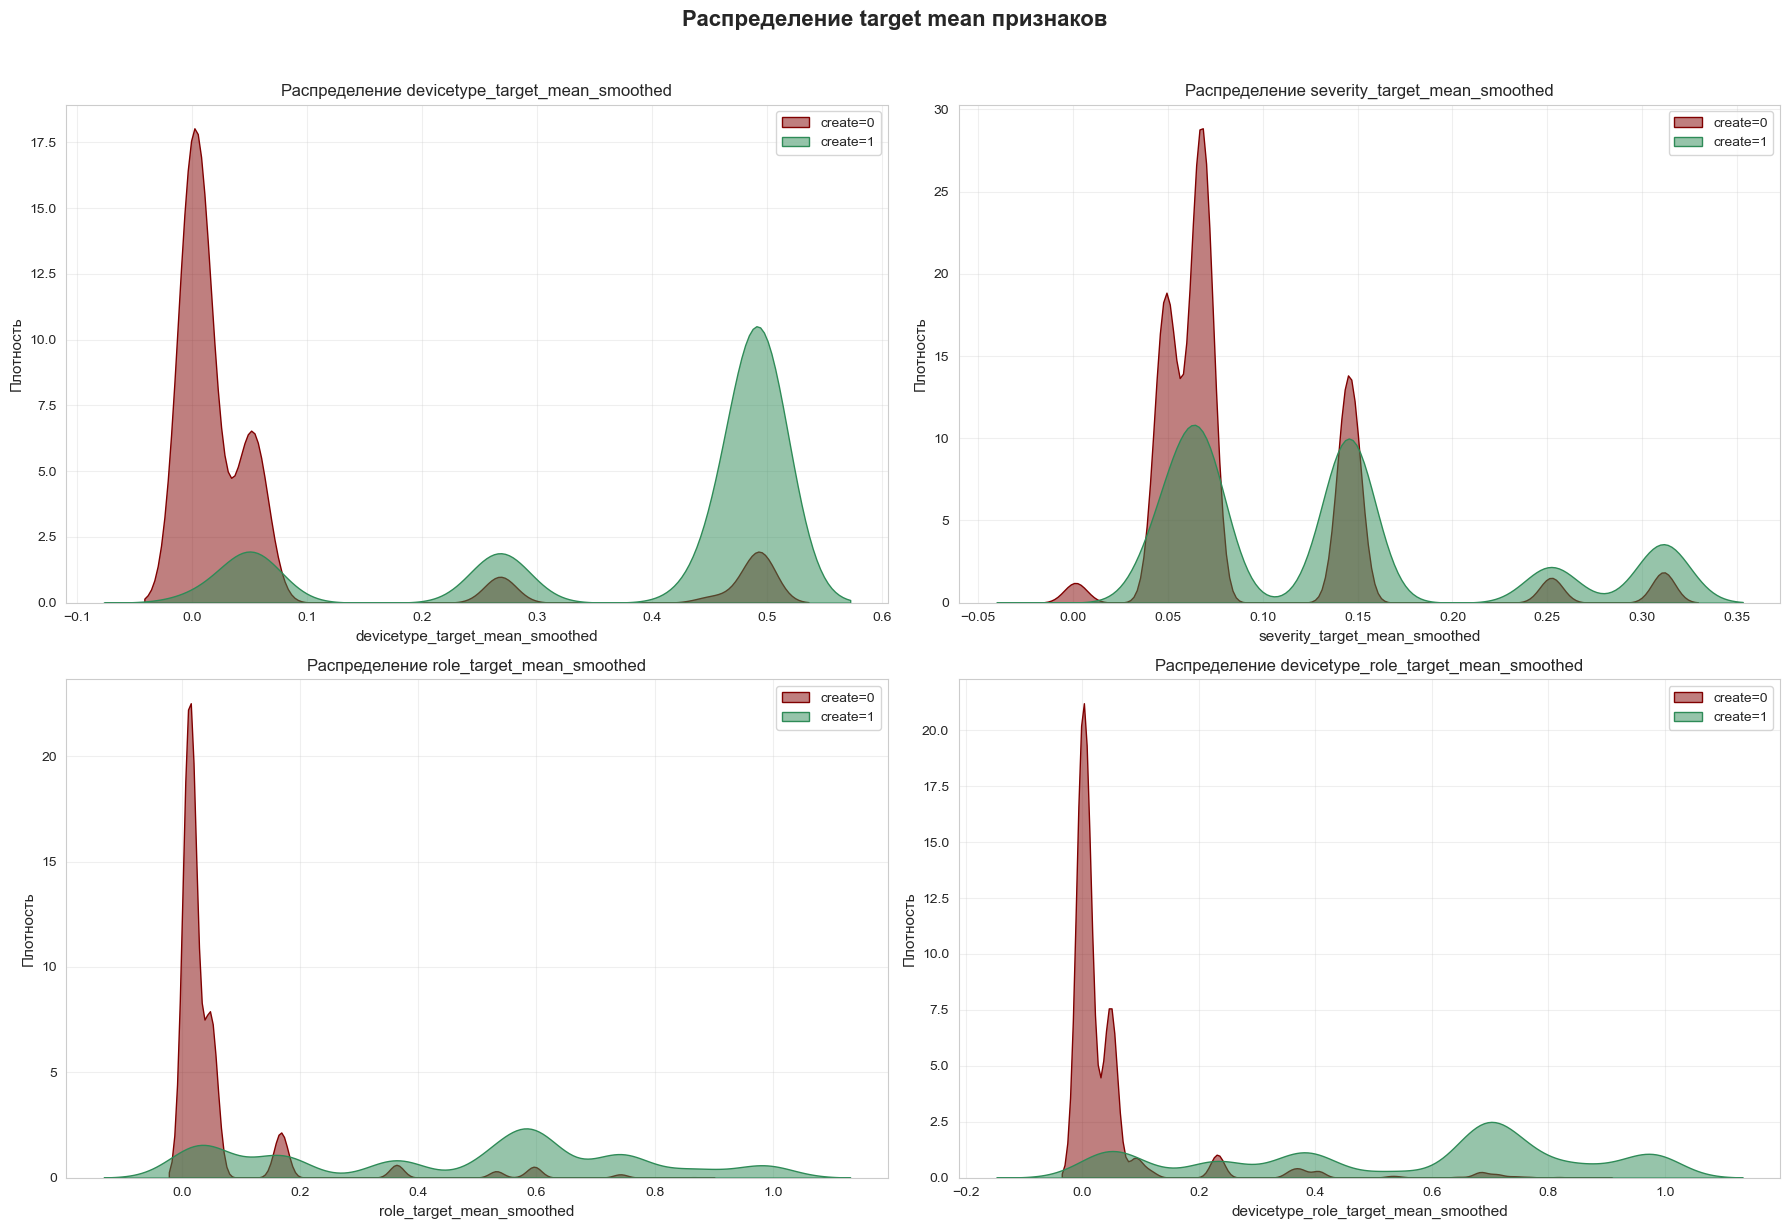

In [17]:
# 2. Target mean признаки
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Распределение target mean признаков', fontsize=16, fontweight='bold', y=1.02)

target_cols = ['devicetype_target_mean_smoothed', 'severity_target_mean_smoothed', 
               'role_target_mean_smoothed',
               'devicetype_role_target_mean_smoothed']

for i, col in enumerate(target_cols):
    if col in df_features.columns:
        ax = axes[i//2, i%2]
        
        # Разделяем по create
        data_0 = df_features[df_features['create'] == 0][col]
        data_1 = df_features[df_features['create'] == 1][col]
        
        # Строим KDE plot
        sns.kdeplot(data=data_0, label='create=0', color='maroon', ax=ax, fill=True, alpha=0.5)
        sns.kdeplot(data=data_1, label='create=1', color='seagreen', ax=ax, fill=True, alpha=0.5)
        
        ax.set_xlabel(col, fontsize=11)
        ax.set_ylabel('Плотность', fontsize=11)
        # Плотность распределения показывает, насколько вероятно встретить то или иное значение в данных.
        ax.set_title(f'Распределение {col}', fontsize=12)
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


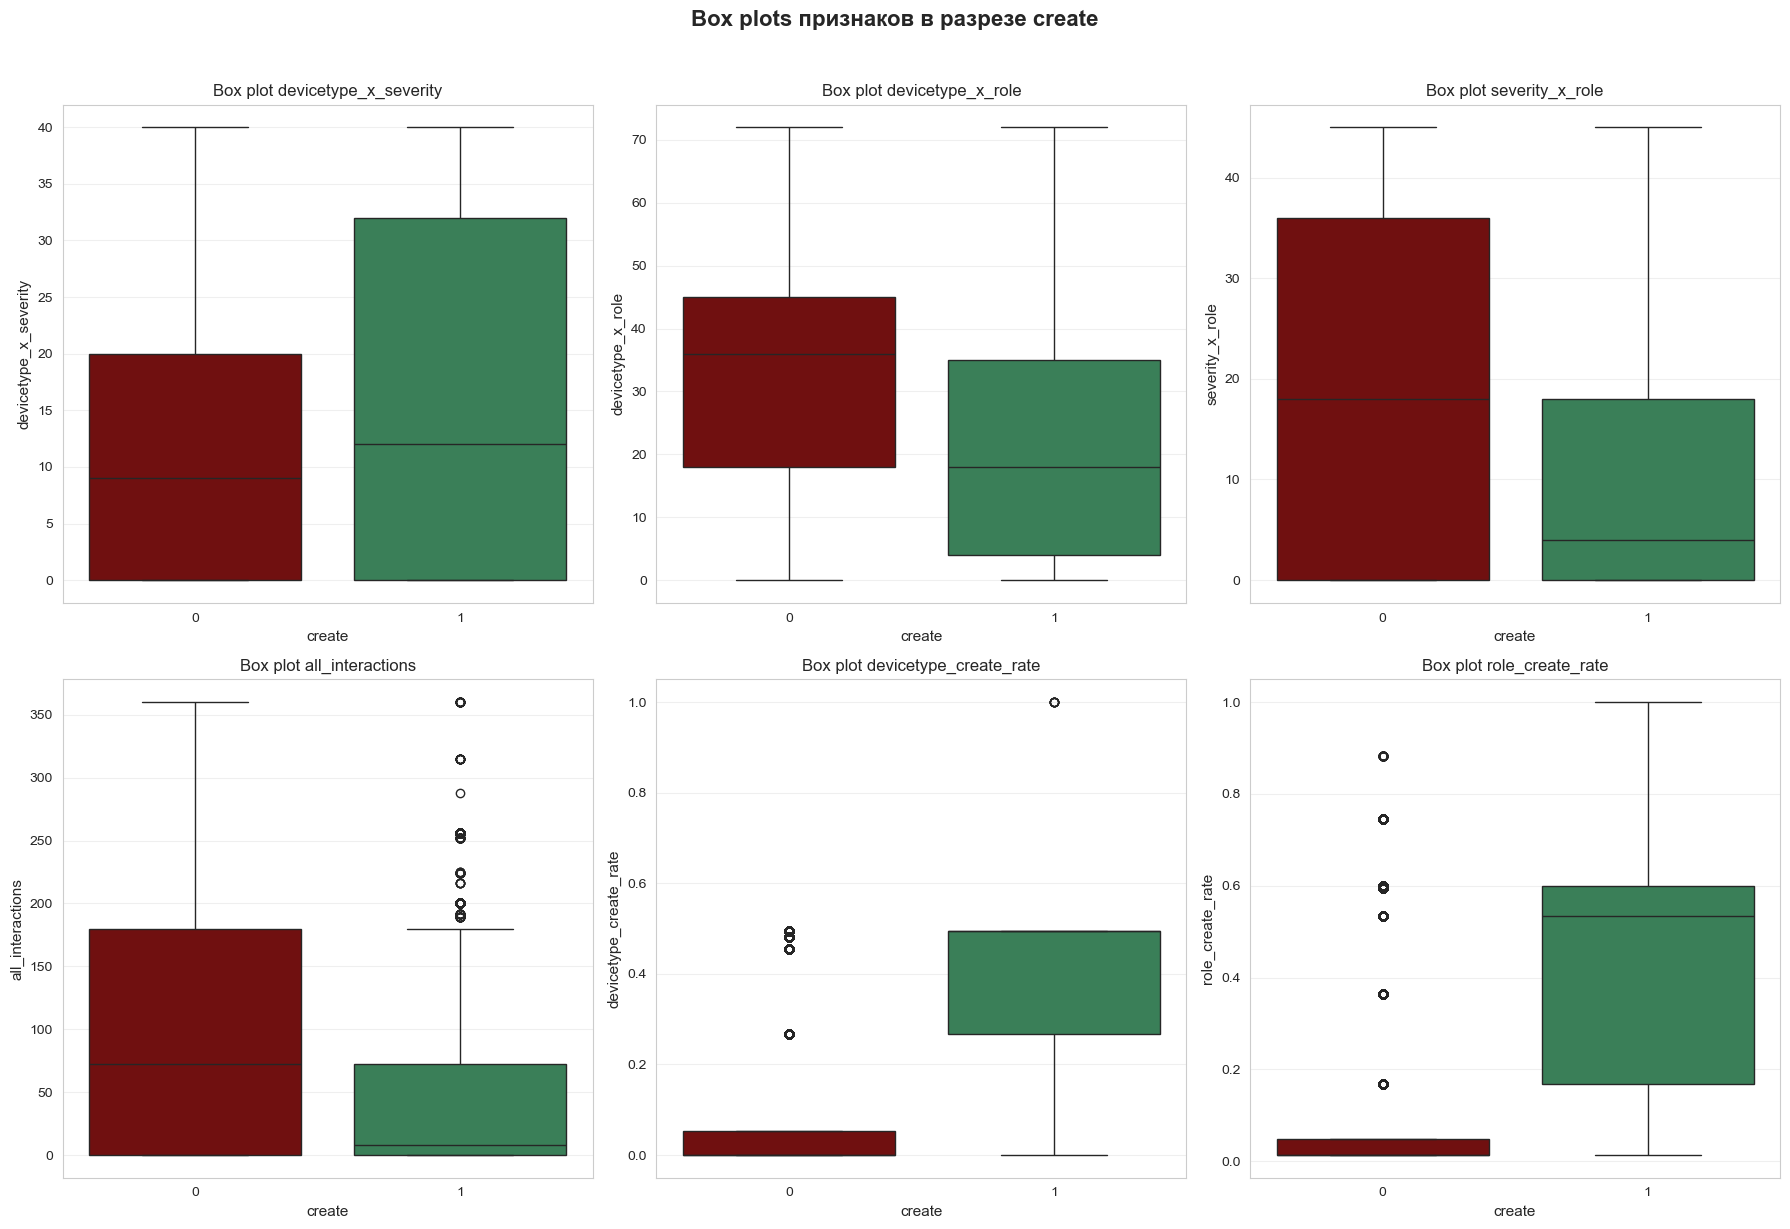

In [18]:
# 3. Box plots для числовых признаков
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Box plots признаков в разрезе create', fontsize=16, fontweight='bold', y=1.02)

numeric_cols = ['devicetype_x_severity', 'devicetype_x_role', 'severity_x_role',
                'all_interactions', 'devicetype_create_rate', 'role_create_rate']

for i, col in enumerate(numeric_cols):
    if col in df_features.columns:
        ax = axes[i//3, i%3]
        
        # Создаем DataFrame для boxplot
        plot_df = pd.DataFrame({
            'create': df_features['create'],
            'value': df_features[col]
        })
        
        sns.boxplot(data=plot_df, x='create', y='value', ax=ax, 
                   palette=['maroon', 'seagreen'])
        
        ax.set_xlabel('create', fontsize=11)
        ax.set_ylabel(col, fontsize=11)
        ax.set_title(f'Box plot {col}', fontsize=12)
        ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

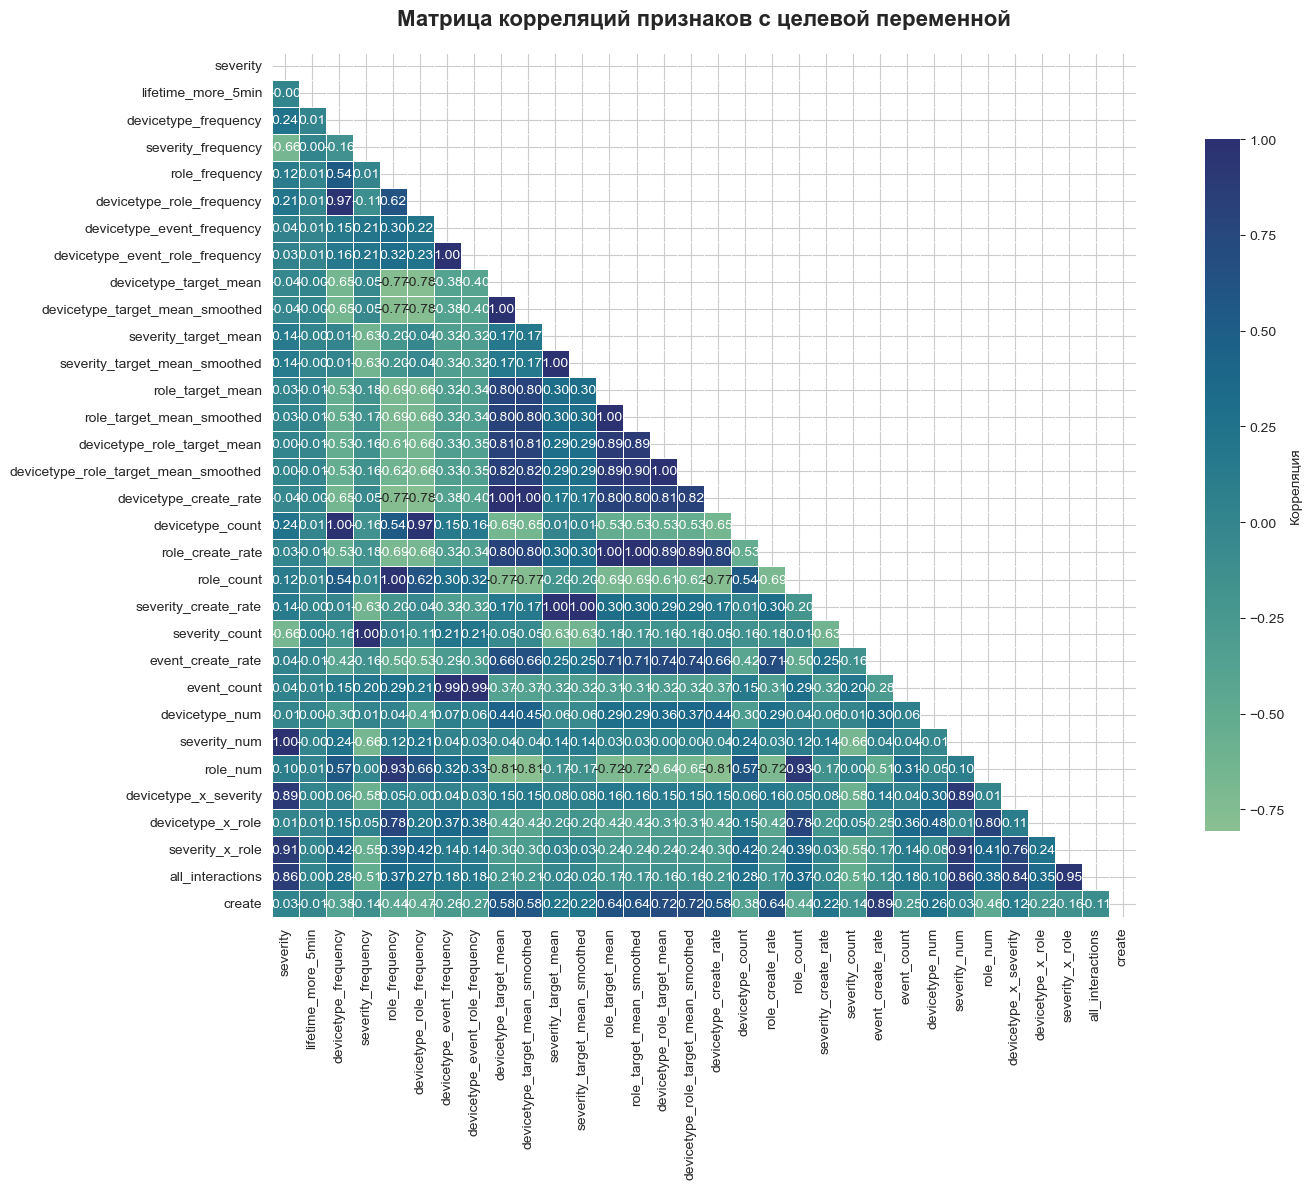

In [19]:
# Анализ корреляции признаков:

# Выбираем числовые признаки для корреляционного анализа
numeric_features = df_features.select_dtypes(include=[np.number]).columns.tolist()

# Удаляем целевую переменную из списка признаков для корреляции
if 'create' in numeric_features:
    numeric_features.remove('create')

# Создаем матрицу корреляций
corr_matrix = df_features[numeric_features + ['create']].corr()

# Тепловая карта корреляций
fig, ax = plt.subplots(figsize=(16, 12))

# Маска для верхнего треугольника
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Тепловая карта
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='crest',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8, "label": "Корреляция"})

ax.set_title('Матрица корреляций признаков с целевой переменной', 
             fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


In [20]:
# Корреляции с целевой переменной

# print("Корреляции признаков с целевой переменной create (топ 10):")
# corr_with_target = corr_matrix['create'].drop('create').sort_values(ascending=False)

# print(f'\n{corr_with_target.head(10)}')

# Корреляции с целевой переменной
print("\nКорреляции признаков с целевой переменной create:")
corr_with_target = corr_matrix['create'].drop('create').sort_values(ascending=False)
for feat, corr in corr_with_target.head(10).items():
    print(f"  {feat}: {corr:.3f}")

print("\nПризнаки с отрицательной корреляцией:")
for feat, corr in corr_with_target.tail(10).items():
    print(f"  {feat}: {corr:.3f}")

# Поиск сильно скоррелированных признаков (>0.8)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'feature1': corr_matrix.columns[i],
                'feature2': corr_matrix.columns[j],
                'correlation': corr_matrix.iloc[i, j]
            })


Корреляции признаков с целевой переменной create:
  event_create_rate: 0.890
  devicetype_role_target_mean: 0.716
  devicetype_role_target_mean_smoothed: 0.715
  role_target_mean: 0.639
  role_create_rate: 0.639
  role_target_mean_smoothed: 0.639
  devicetype_target_mean: 0.583
  devicetype_create_rate: 0.583
  devicetype_target_mean_smoothed: 0.582
  devicetype_num: 0.259

Признаки с отрицательной корреляцией:
  devicetype_x_role: -0.222
  event_count: -0.252
  devicetype_event_frequency: -0.260
  devicetype_event_role_frequency: -0.270
  devicetype_frequency: -0.376
  devicetype_count: -0.376
  role_count: -0.440
  role_frequency: -0.440
  role_num: -0.461
  devicetype_role_frequency: -0.475



Признаки с сильной корреляцией (>0.8):
  devicetype_event_frequency <-> event_count: 0.994
  devicetype_event_role_frequency <-> event_count: 0.993
  devicetype_frequency <-> devicetype_role_frequency: 0.968
  devicetype_role_frequency <-> devicetype_count: 0.968
  severity_x_role <-> all_interactions: 0.949
  role_frequency <-> role_num: 0.929
  role_count <-> role_num: 0.929
  severity <-> severity_x_role: 0.908
  severity_num <-> severity_x_role: 0.908
  role_target_mean_smoothed <-> devicetype_role_target_mean_smoothed: 0.895


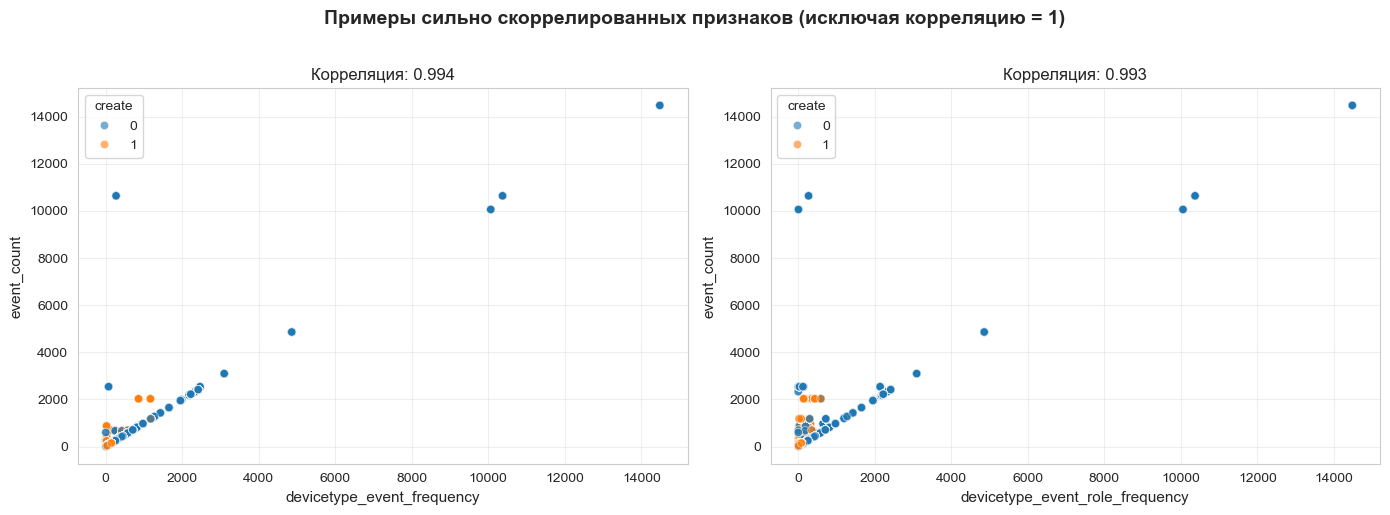

In [21]:
print("\nПризнаки с сильной корреляцией (>0.8):")
if high_corr_pairs:
    # Фильтруем пары, убирая корреляции равные 1
    filtered_pairs = [pair for pair in high_corr_pairs if abs(pair['correlation']) < 0.999]
    
    if filtered_pairs:
        # Сортируем по абсолютной корреляции
        filtered_pairs = sorted(filtered_pairs, key=lambda x: abs(x['correlation']), reverse=True)
        
        for pair in filtered_pairs[:10]:  # Показываем топ-10
            print(f"  {pair['feature1']} <-> {pair['feature2']}: {pair['correlation']:.3f}")
        
        # Визуализация сильно скоррелированных признаков
        if len(filtered_pairs) >= 2:
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            
            # Берем две пары с самой высокой корреляцией (но не 1)
            for idx, pair in enumerate(filtered_pairs[:2]):
                ax = axes[idx]
                sns.scatterplot(data=df_features, x=pair['feature1'], y=pair['feature2'],
                              hue='create', palette=['#1f77b4', '#ff7f0e'], 
                              alpha=0.6, ax=ax)
                ax.set_xlabel(pair['feature1'], fontsize=11)
                ax.set_ylabel(pair['feature2'], fontsize=11)
                ax.set_title(f'Корреляция: {pair["correlation"]:.3f}', fontsize=12)
                ax.legend(title='create')
                ax.grid(True, alpha=0.3)
            
            plt.suptitle('Примеры сильно скоррелированных признаков (исключая корреляцию = 1)', 
                        fontsize=14, fontweight='bold', y=1.02)
            plt.tight_layout()
            plt.show()
    else:
        print("  После удаления корреляций = 1 не осталось пар для визуализации")

In [22]:
# Подготовливаем признаки для модели

selected_features = [
    # Оригинальные закодированные признаки
    'devicetype_encoded', 'severity_encoded', 'role_encoded',
    
    # Частотные признаки
    'devicetype_frequency', 'severity_frequency', 'role_frequency',
    'devicetype_severity_frequency', 'devicetype_role_frequency', 
	'devicetype_event_frequency', 'devicetype_event_role_frequency',
	'devicetype_severity_role_frequency',
    
    # Target mean признаки (сглаженные)
    'devicetype_target_mean_smoothed', 'severity_target_mean_smoothed',
    'role_target_mean_smoothed', 'devicetype_severity_target_mean_smoothed',
    'devicetype_role_target_mean_smoothed', 'severity_role_target_mean_smoothed',
    
    # Статистические признаки
    'devicetype_create_rate', 'role_create_rate', 'event_create_rate',
    'devicetype_count', 'role_count', 'severity_count',
    
    # Мультипликативные признаки
    'devicetype_x_severity', 'devicetype_x_role', 'severity_x_role', 'all_interactions'
]

# Проверяем, какие признаки действительно есть в данных
available_features = [f for f in selected_features if f in df_features.columns]
log(f"Используется признаков ({len(available_features)}):")
log(f"{(available_features)}")

# Создаем матрицу признаков
X_create = df_features[available_features].copy()

# Кодируем целевую переменную
y_create = train_create_df['create'].values

# Масштабирование признаков (опционально)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_create_scaled = scaler.fit_transform(X_create)
X_create_scaled = pd.DataFrame(X_create_scaled, columns=X_create.columns)

[DEBUG] Используется признаков (20):
[DEBUG] ['devicetype_frequency', 'severity_frequency', 'role_frequency', 'devicetype_role_frequency', 'devicetype_event_frequency', 'devicetype_event_role_frequency', 'devicetype_target_mean_smoothed', 'severity_target_mean_smoothed', 'role_target_mean_smoothed', 'devicetype_role_target_mean_smoothed', 'devicetype_create_rate', 'role_create_rate', 'event_create_rate', 'devicetype_count', 'role_count', 'severity_count', 'devicetype_x_severity', 'devicetype_x_role', 'severity_x_role', 'all_interactions']


In [23]:
# Обучаем классификатор с балансировкой классов
create_classifier = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    min_samples_split=8,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

create_classifier.fit(X_create_scaled, y_create)

log("Модель обучена.")

[DEBUG] Модель обучена.



  Точность модели на тестовой выборке: 97.93%
  Матрица ошибок:
    TN: 17204  FP:  310
    FN:   89  TP: 1707

  Classification Report:
              precision    recall  f1-score   support

    create=0       0.99      0.98      0.99     17514
    create=1       0.85      0.95      0.90      1796

    accuracy                           0.98     19310
   macro avg       0.92      0.97      0.94     19310
weighted avg       0.98      0.98      0.98     19310


  Топ-15 наиболее важных признаков:
    event_create_rate: 0.316
    devicetype_event_role_frequency: 0.103
    devicetype_role_target_mean_smoothed: 0.101
    devicetype_role_frequency: 0.100
    devicetype_count: 0.082
    devicetype_frequency: 0.073
    devicetype_target_mean_smoothed: 0.051
    devicetype_create_rate: 0.051
    devicetype_event_frequency: 0.049
    role_frequency: 0.016
    role_create_rate: 0.015
    role_count: 0.014
    role_target_mean_smoothed: 0.012
    devicetype_x_role: 0.005
    all_interactions: 0.

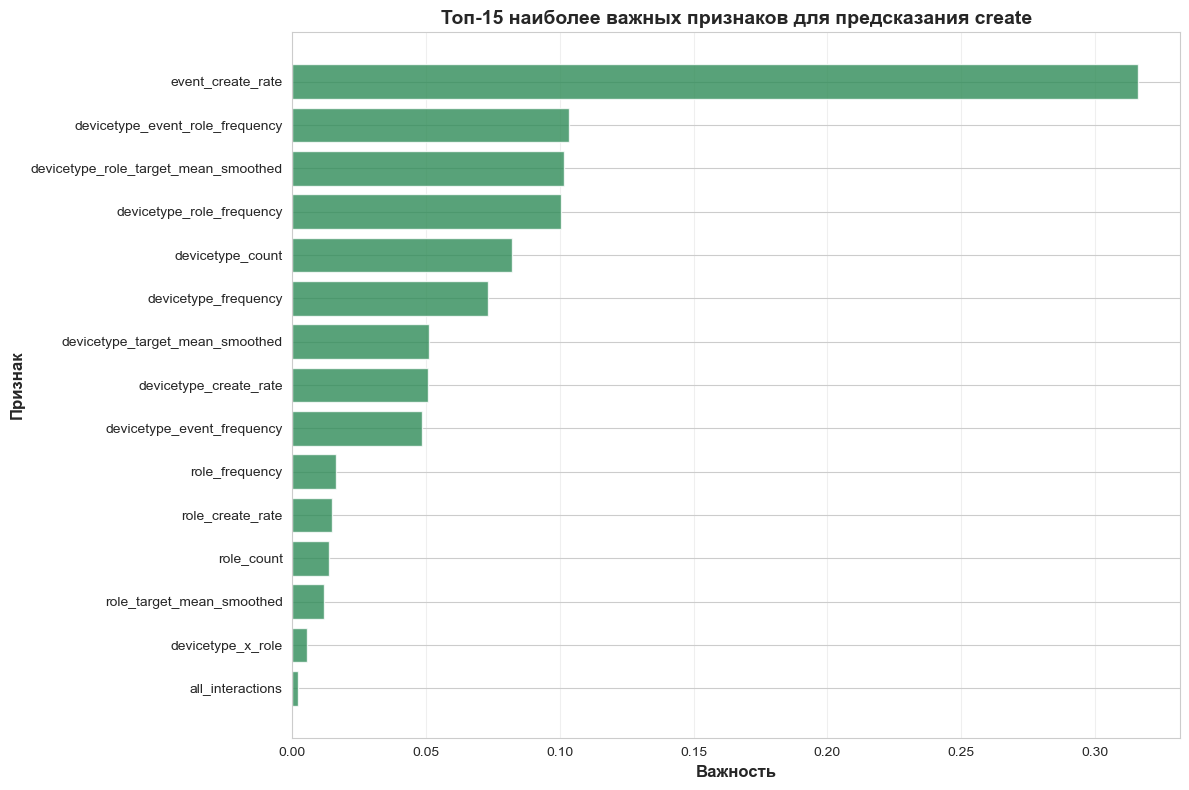

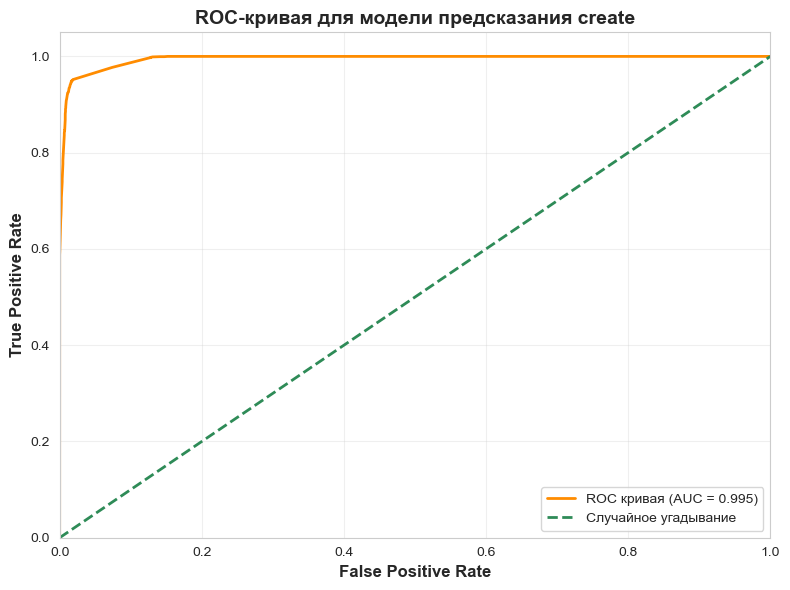


 ROC-AUC score: 0.995


In [24]:
# Оценка качества модели


if len(train_create_df) >= 100:
    X_train, X_test, y_train, y_test = train_test_split(
        X_create_scaled, y_create, test_size=0.2, random_state=42, stratify=y_create
    )
    create_classifier.fit(X_train, y_train)
    y_pred = create_classifier.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"\n  Точность модели на тестовой выборке: {accuracy:.2%}")
    
    # Матрица ошибок
    cm = confusion_matrix(y_test, y_pred)
    print("  Матрица ошибок:")
    print(f"    TN: {cm[0,0]:4d}  FP: {cm[0,1]:4d}")
    print(f"    FN: {cm[1,0]:4d}  TP: {cm[1,1]:4d}")
    
    # Precision, Recall, F1-score
    from sklearn.metrics import classification_report
    print("\n  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['create=0', 'create=1']))
    
    # Важность признаков
    feature_importance = pd.DataFrame({
        'feature': available_features,
        'importance': create_classifier.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\n  Топ-15 наиболее важных признаков:")
    for _, row in feature_importance.head(15).iterrows():
        print(f"    {row['feature']}: {row['importance']:.3f}")
    
    # Визуализация важности признаков
    fig, ax = plt.subplots(figsize=(12, 8))
    
    top_features = feature_importance.head(15).sort_values('importance', ascending=True)
    
    ax.barh(top_features['feature'], top_features['importance'], 
            color='seagreen', alpha=0.8)
    ax.set_xlabel('Важность', fontsize=12, fontweight='bold')
    ax.set_ylabel('Признак', fontsize=12, fontweight='bold')
    ax.set_title('Топ-15 наиболее важных признаков для предсказания create', 
                 fontsize=14, fontweight='bold')
    ax.grid(True, axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # ROC-AUC кривая
    from sklearn.metrics import roc_curve, auc, roc_auc_score
    
    y_score = create_classifier.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    ax.plot(fpr, tpr, color='darkorange', lw=2, 
            label=f'ROC кривая (AUC = {roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], color='seagreen', lw=2, linestyle='--', label='Случайное угадывание')
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    ax.set_title('ROC-кривая для модели предсказания create', fontsize=14, fontweight='bold')
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n ROC-AUC score: {roc_auc:.3f}")

# Тестирование модели на файле с пропусками типов устройств, ролями и пустым целевым признакосм создания ТТ.
Модель должна:
1) Заполнить тип устройства по имени,
2) Заполнить роль по типу,
3) Заполнить признак заведения по набору всех признаков совместно.

In [26]:
# Файл с пустыми значениями типа устройства и ролей, а так же признака заведения ТТ
INPUT_FILE = "alerts_real_empty.xlsx"
# INPUT_FILE = "training_full_with_gaps_10.xlsx"

df_input = load_excel_file(INPUT_FILE)
if df_input is None:
    raise ValueError("Не удалось загрузить файл для обработки")
    
    
log(f"\nВсего записей: {len(df_input)}")
print(f'\n\nДатасет с незаполненными полями:')
# Создаем копию для отображения результата
show(df_input)

# Создаем копию для результата
df_result = df_input.copy()

# Добавляем колонки для метаданных
df_result['devicetype_confidence'] = None
df_result['devicetype_alternatives'] = None
df_result['role_confidence'] = None
df_result['create_probability'] = None
df_result['create_confidence'] = None

print(f'\n\nДатасет для обработки предсказательной модели со столбцами метаданных:')
show(df_result)

[DEBUG] Загружено 1000 строк из файла: alerts_real_empty.xlsx
[DEBUG]  Колонки: ['name', 'devicetype', 'severity', 'event', 'role', 'lifetime_more_5min', 'create']
 Информация о получившемся датафрейме:
[DEBUG] 
Всего записей: 1000


Датасет с незаполненными полями:


,name,devicetype,severity,event,role,lifetime_more_5min,create
0,Данные скрыты,NaN,0,10.237,NaN,0,NaN
1,Данные скрыты,NaN,0,11.5,NaN,0,NaN
2,Данные скрыты,NaN,0,10.237,NaN,0,NaN
3,Данные скрыты,NaN,0,10.237,NaN,0,NaN
4,Данные скрыты,NaN,0,10.237,NaN,0,NaN




Датасет для обработки предсказательной модели со столбцами метаданных:


,name,devicetype,severity,event,role,lifetime_more_5min,create,devicetype_confidence,devicetype_alternatives,role_confidence,create_probability,create_confidence
0,Данные скрыты,NaN,0,10.237,NaN,0,NaN,None,None,None,None,None
1,Данные скрыты,NaN,0,11.5,NaN,0,NaN,None,None,None,None,None
2,Данные скрыты,NaN,0,10.237,NaN,0,NaN,None,None,None,None,None
3,Данные скрыты,NaN,0,10.237,NaN,0,NaN,None,None,None,None,None
4,Данные скрыты,NaN,0,10.237,NaN,0,NaN,None,None,None,None,None


In [27]:
# Предсказание пропущенных devicetype

missing_device_mask = df_result['devicetype'].isna()
missing_count = missing_device_mask.sum()

if missing_count > 0:
    log(f"Найдено пропусков devicetype: {missing_count}")
    
    names_to_predict = df_result.loc[missing_device_mask, 'name'].tolist()
    predictions = predict_device_type(names_to_predict)
    
    # Заполняем пропуски
    filled_count = 0
    for i, (idx, pred) in enumerate(zip(df_result[missing_device_mask].index, predictions)):
        if pred['confidence'] > 0.3:  # Порог уверенности
            df_result.loc[idx, 'devicetype'] = pred['predicted_type']
            df_result.loc[idx, 'devicetype_confidence'] = pred['confidence']
            filled_count += 1
            
            # Добавляем топ-3 варианта
            if pred['top_3']:
                top3_str = '; '.join([f"{t['type']}({t['probability']:.1%})" 
                                     for t in pred['top_3']])
                df_result.loc[idx, 'devicetype_alternatives'] = top3_str
    
    log(f" Заполнено {filled_count} из {missing_count} пропусков devicetype")
    print(f'\n\nДатасет для обработки теперь выглялит так:')
    ##################################################

    show(df_result)
else:
    log("Пропусков devicetype не найдено")



[DEBUG] Найдено пропусков devicetype: 1000
[DEBUG]  Заполнено 1000 из 1000 пропусков devicetype


Датасет для обработки теперь выглялит так:


,name,devicetype,severity,event,role,lifetime_more_5min,create,devicetype_confidence,devicetype_alternatives,role_confidence,create_probability,create_confidence
0,Данные скрыты,eNodeB,0,10.237,NaN,0,NaN,0.737735,eNodeB(73.8%); Cell(23.7%),None,None,None
1,Данные скрыты,eNodeB,0,11.5,NaN,0,NaN,0.737735,eNodeB(73.8%); Cell(23.7%),None,None,None
2,Данные скрыты,eNodeB,0,10.237,NaN,0,NaN,0.737735,eNodeB(73.8%); Cell(23.7%),None,None,None
3,Данные скрыты,eNodeB,0,10.237,NaN,0,NaN,0.737735,eNodeB(73.8%); Cell(23.7%),None,None,None
4,Данные скрыты,eNodeB,0,10.237,NaN,0,NaN,0.737735,eNodeB(73.8%); Cell(23.7%),None,None,None


In [28]:
# Заполнение role по справочнику

missing_role_mask = df_result['role'].isna()
missing_count = missing_role_mask.sum()

if missing_count > 0:
    log(f"Найдено пропусков role: {missing_count}")
    
    device_types = df_result.loc[missing_role_mask, 'devicetype'].tolist()
    # Заменяем None на 'Unknown'
    device_types = [dt if dt is not None else 'Unknown' for dt in device_types]
    
    role_predictions = predict_role(device_types)
    
    filled_count = 0
    filled_data = []
    for i, (idx, pred) in enumerate(zip(df_result[missing_role_mask].index, role_predictions)):
        if pred['confidence'] > 0:
            df_result.loc[idx, 'role'] = pred['role']
            df_result.loc[idx, 'role_confidence'] = pred['confidence']
            filled_count += 1
            filled_data.append({
                '№': filled_count,
                'Индекс': idx,
                'Тип устройства': pred['name'][:50] + '...' if len(pred['name']) > 50 else pred['name'],
                'Предсказанная роль': pred['role'],
                'Уверенность': f"{pred['confidence']:.1%}",
                'Альтернативы': top3_str[:60] + '...' if len(top3_str) > 60 else top3_str
            })
                    
    
    log(f" Заполнено {filled_count} из {missing_count} пропусков role")
    print(f'\n\nДатасет для обработки теперь выглялит так:')
    show(df_result)
else:
    log("Пропусков role не найдено")



[DEBUG] Найдено пропусков role: 1000
[DEBUG]  Заполнено 1000 из 1000 пропусков role


Датасет для обработки теперь выглялит так:


,name,devicetype,severity,event,role,lifetime_more_5min,create,devicetype_confidence,devicetype_alternatives,role_confidence,create_probability,create_confidence
0,Данные скрыты,eNodeB,0,10.237,Поддержка БС,0,NaN,0.737735,eNodeB(73.8%); Cell(23.7%),0.328001,None,None
1,Данные скрыты,eNodeB,0,11.5,Поддержка БС,0,NaN,0.737735,eNodeB(73.8%); Cell(23.7%),0.328001,None,None
2,Данные скрыты,eNodeB,0,10.237,Поддержка БС,0,NaN,0.737735,eNodeB(73.8%); Cell(23.7%),0.328001,None,None
3,Данные скрыты,eNodeB,0,10.237,Поддержка БС,0,NaN,0.737735,eNodeB(73.8%); Cell(23.7%),0.328001,None,None
4,Данные скрыты,eNodeB,0,10.237,Поддержка БС,0,NaN,0.737735,eNodeB(73.8%); Cell(23.7%),0.328001,None,None


In [29]:
# Предсказание самого главного вопроса: create =0 или 1

missing_create_mask = df_result['create'].isna()
missing_count = missing_create_mask.sum()

if missing_count > 0:
    log(f"Найдено пропусков create: {missing_count}")
    
    # Берем все строки с пропущенным create
    device_types = df_result.loc[missing_create_mask, 'devicetype'].tolist()
    # ВАЖНО: преобразуем severity В СТРОКИ так же, как при обучении!
    severities_raw = df_result.loc[missing_create_mask, 'severity'].tolist()
    severities = [str(s) if s is not None else 'Unknown' for s in severities_raw]  # ЯВНОЕ ПРЕОБРАЗОВАНИЕ В СТРОКИ
    roles = df_result.loc[missing_create_mask, 'role'].tolist()
    events = df_result.loc[missing_create_mask, 'event'].tolist()
    
    # Заменяем None на 'Unknown' для предсказания
    device_types = [dt if dt is not None else 'Unknown' for dt in device_types]
    roles = [r if r is not None else 'Unknown' for r in roles]
    events = [ev if ev is not None else 'Unknown' for ev in events]
    
    predictions = predict_create(device_types, severities, roles, events)
    
    filled_count = 0
    for i, (idx, pred) in enumerate(zip(df_result[missing_create_mask].index, predictions)):
        df_result.loc[idx, 'create'] = pred['create']
        df_result.loc[idx, 'create_probability'] = pred['probability_class1']
        df_result.loc[idx, 'create_confidence'] = pred['confidence']
        filled_count += 1
    
    log(f" Заполнено {filled_count} из {missing_count} пропусков create")
    print(f'\n\nДатасет после обработки теперь выглялит так:')
    show(df_result)
else:
    log("Пропусков create не найдено")


[DEBUG] Найдено пропусков create: 1000
 Создание target mean признаков...
[DEBUG] Создано 1000 предсказаний
[DEBUG]  Заполнено 1000 из 1000 пропусков create


Датасет после обработки теперь выглялит так:


,name,devicetype,severity,event,role,lifetime_more_5min,create,devicetype_confidence,devicetype_alternatives,role_confidence,create_probability,create_confidence
0,Данные скрыты,eNodeB,0,10.237,Поддержка БС,0,0.0,0.737735,eNodeB(73.8%); Cell(23.7%),0.328001,0.134828,0.865172
1,Данные скрыты,eNodeB,0,11.5,Поддержка БС,0,0.0,0.737735,eNodeB(73.8%); Cell(23.7%),0.328001,0.134828,0.865172
2,Данные скрыты,eNodeB,0,10.237,Поддержка БС,0,0.0,0.737735,eNodeB(73.8%); Cell(23.7%),0.328001,0.134828,0.865172
3,Данные скрыты,eNodeB,0,10.237,Поддержка БС,0,0.0,0.737735,eNodeB(73.8%); Cell(23.7%),0.328001,0.134828,0.865172
4,Данные скрыты,eNodeB,0,10.237,Поддержка БС,0,0.0,0.737735,eNodeB(73.8%); Cell(23.7%),0.328001,0.134828,0.865172


# Оценка качества предсказательной способности модели
Процент присвоения признака заведения на:
1) Большом количестве данных, на которых модель была обучена.
2) Реальных данных с очищенными столбцами.
3) Реальных данных до очистки (для сравнения).

In [30]:
# Файл с пустыми значениями типа устройства и ролей, а так же признака заведения ТТ
INPUT_FILE = "alerts_real_filled.xlsx"

df_input_real = load_excel_file(INPUT_FILE)
if df_input_real is None:
    raise ValueError("Не удалось загрузить файл для обработки")
    
    
log(f"\nВсего записей: {len(df_input_real)}")
print(f'\n\nДатасет с заполненными полями:')
show(df_input_real)


[DEBUG] Загружено 1000 строк из файла: alerts_real_filled.xlsx
[DEBUG]  Колонки: ['name', 'devicetype', 'severity', 'event', 'role', 'lifetime_more_5min', 'create']
 Информация о получившемся датафрейме:
[DEBUG] 
Всего записей: 1000


Датасет с заполненными полями:


,name,devicetype,severity,event,role,lifetime_more_5min,create
0,Данные скрыты,BTS,0,10.237,Поддержка БС,0,0
1,Данные скрыты,BTS,0,11.5,Отдел роуминга,0,0
2,Данные скрыты,BTS,0,10.237,Поддержка БС,0,0
3,Данные скрыты,BTS,0,10.237,Поддержка БС,0,0
4,Данные скрыты,BTS,0,10.237,Поддержка БС,0,0


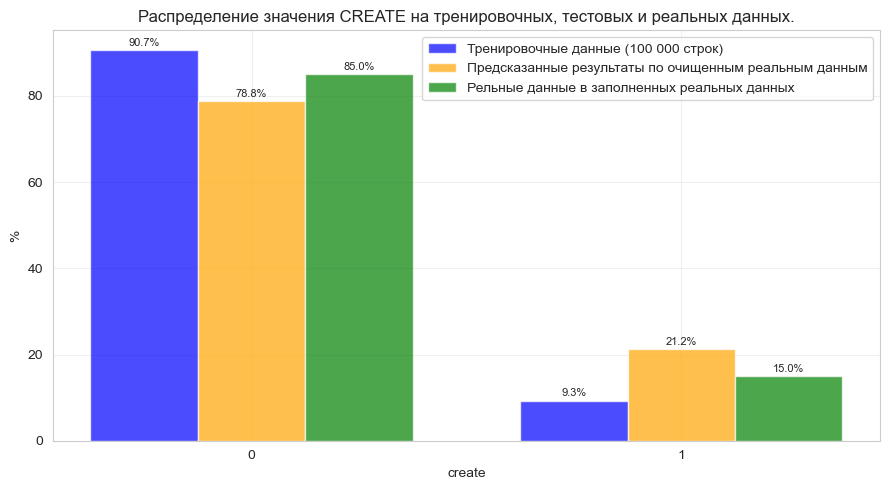

In [31]:
# Сравнение файлов на котором происходила проверка работы модели с неочищенным тем же файлом

train_stats = {
    'create=1': (train_create_df['create'] == 1).sum(),
    'create=0': (train_create_df['create'] == 0).sum()
}

result_stats = {
    'create=1': (df_result['create'] == 1).sum(),
    'create=0': (df_result['create'] == 0).sum()
}

real_stats = {
    'create=1': (df_input_real['create'] == 1).sum(),
    'create=0': (df_input_real['create'] == 0).sum()
}

# Вычисляем проценты
train_total = len(train_create_df)
result_total = len(df_result)
real_total = len(df_input_real)

train_pct = {
    'create=1': (train_stats['create=1'] / train_total) * 100,
    'create=0': (train_stats['create=0'] / train_total) * 100
}
result_pct = {
    'create=1': (result_stats['create=1'] / result_total) * 100,
    'create=0': (result_stats['create=0'] / result_total) * 100
}
real_pct = {
    'create=1': (real_stats['create=1'] / real_total) * 100,
    'create=0': (real_stats['create=0'] / real_total) * 100
}

# Цвета
colors_train = ['#1f77b4', '#ff7f0e']  # синий и оранжевый
colors_result = ['#17becf', '#d62728']  # голубой и красный
colors_real = ['seagreen', 'maroon']  # seagreen и maroon

# Построение графика
def plot_create_pcts(train, pred, real, t_total, p_total, r_total):
    t = [train['create=0']/t_total*100, train['create=1']/t_total*100]
    p = [pred['create=0']/p_total*100, pred['create=1']/p_total*100]
    r = [real['create=0']/r_total*100, real['create=1']/r_total*100]
    
    x = np.arange(2)
    w = 0.25
    
    plt.figure(figsize=(9, 5))
    plt.bar(x-w, t, w, label='Тренировочные данные (100 000 строк)', color='blue', alpha=0.7)
    plt.bar(x, p, w, label='Предсказанные результаты по очищенным реальным данным', color='orange', alpha=0.7)
    plt.bar(x+w, r, w, label='Рельные данные в заполненных реальных данных', color='green', alpha=0.7)
    
    plt.xlabel('create')
    plt.ylabel('%')
    plt.title('Распределение значения CREATE на тренировочных, тестовых и реальных данных.')
    plt.xticks(x, ['0', '1'])
    plt.legend()
    plt.grid(alpha=0.3)
    
    for i, v in enumerate(t): plt.text(i-w, v+1, f'{v:.1f}%', ha='center', size=8)
    for i, v in enumerate(p): plt.text(i, v+1, f'{v:.1f}%', ha='center', size=8)
    for i, v in enumerate(r): plt.text(i+w, v+1, f'{v:.1f}%', ha='center', size=8)
    
    plt.tight_layout()
    plt.show()

# Однострочный вызов:
plot_create_pcts(train_stats, result_stats, real_stats, train_total, result_total, real_total)


# Вывод
Предсказательные способности модели не идеальны, однако позволяют угадать нужно ли заводить инцидент о событии с приемлимой точностью.